In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Paths
PROJECT_ROOT = Path().resolve().parent
data_path = PROJECT_ROOT / "data" / "processed"

# Load datasets
df_pt = pd.read_csv(data_path / "portugal.csv", parse_dates=["DateUTC"], index_col="DateUTC")
df_es = pd.read_csv(data_path / "spain.csv", parse_dates=["DateUTC"], index_col="DateUTC")

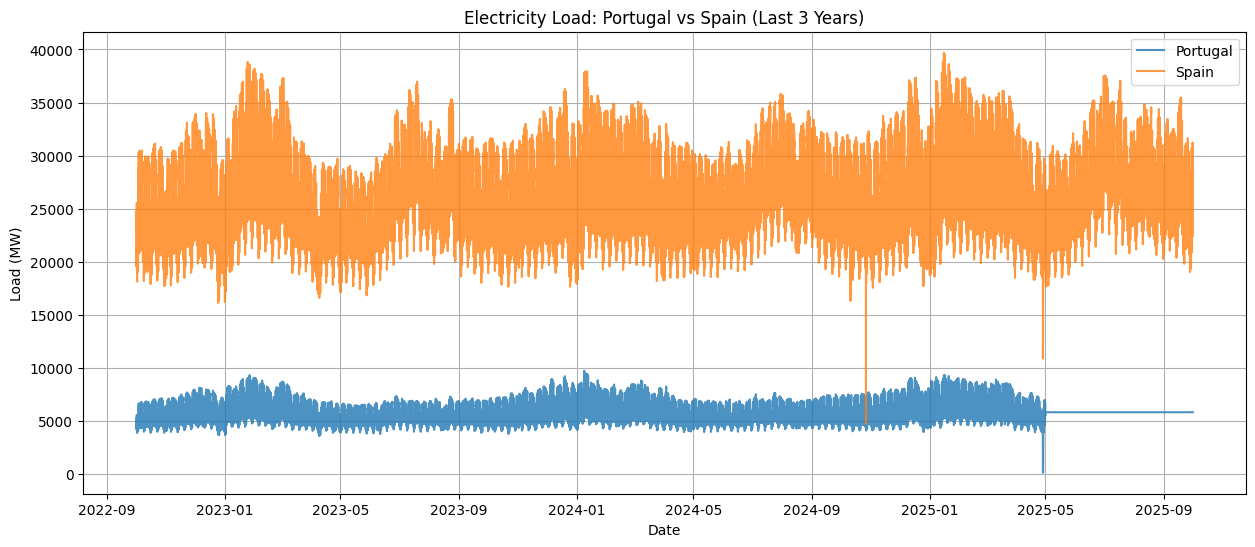

In [4]:
plt.figure(figsize=(15,6))

plt.plot(df_pt.index, df_pt["Value"], label="Portugal", alpha=0.8)
plt.plot(df_es.index, df_es["Value"], label="Spain", alpha=0.8)

plt.title("Electricity Load: Portugal vs Spain (Last 3 Years)")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.legend()
plt.grid(True)

plt.show()

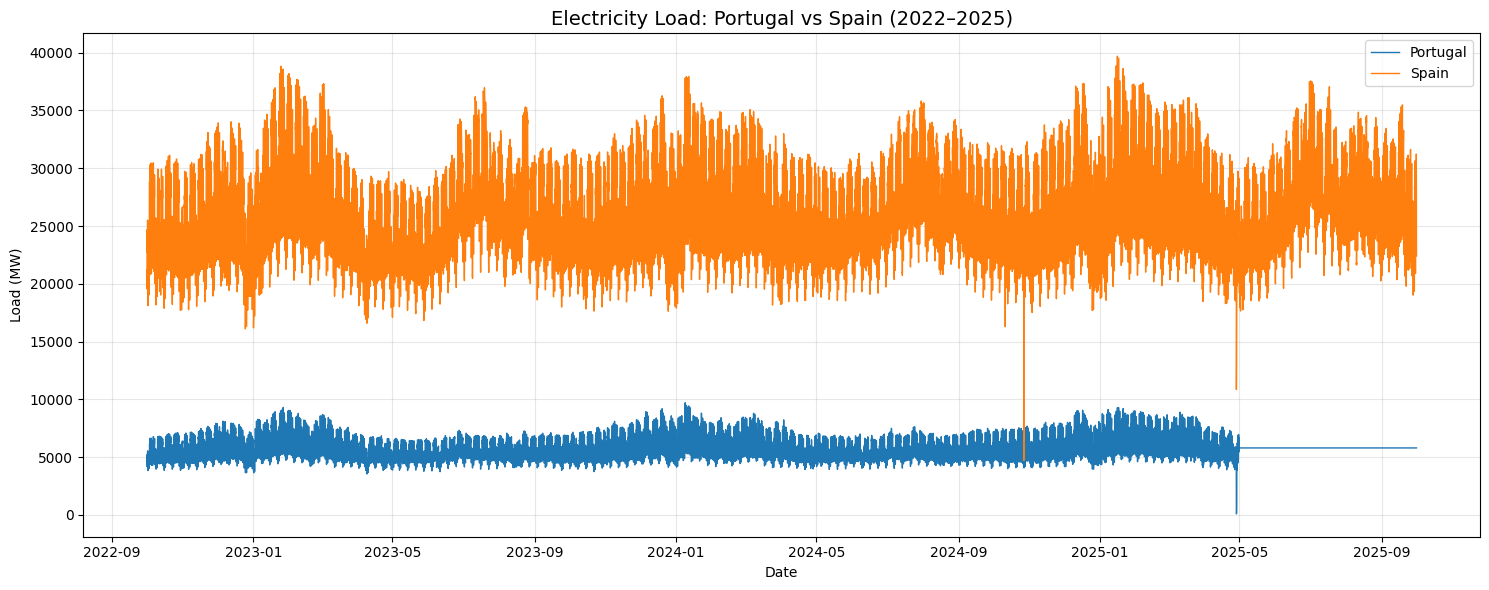

In [5]:
plt.figure(figsize=(15,6))

plt.plot(df_pt.index, df_pt["Value"], label="Portugal", linewidth=1)
plt.plot(df_es.index, df_es["Value"], label="Spain", linewidth=1)

plt.title("Electricity Load: Portugal vs Spain (2022–2025)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

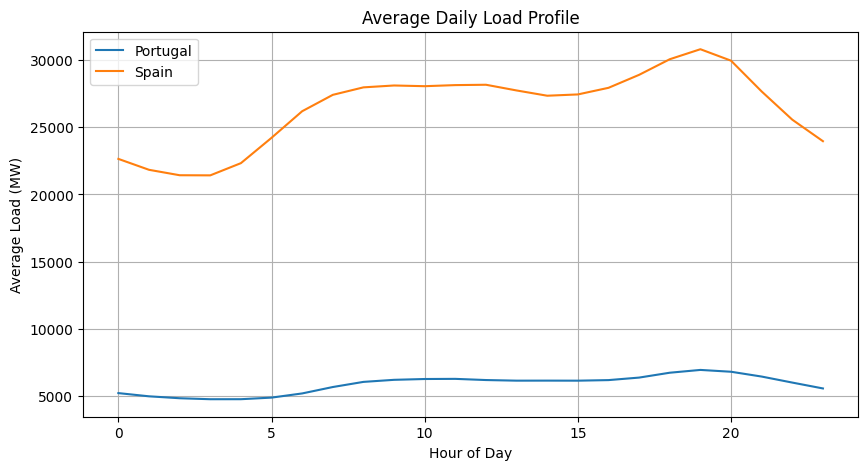

In [6]:
df_pt["hour"] = df_pt.index.hour
df_es["hour"] = df_es.index.hour

pt_hourly = df_pt.groupby("hour")["Value"].mean()
es_hourly = df_es.groupby("hour")["Value"].mean()

plt.figure(figsize=(10,5))

plt.plot(pt_hourly.index, pt_hourly, label="Portugal")
plt.plot(es_hourly.index, es_hourly, label="Spain")

plt.title("Average Daily Load Profile")
plt.xlabel("Hour of Day")
plt.ylabel("Average Load (MW)")
plt.legend()
plt.grid(True)

plt.show()

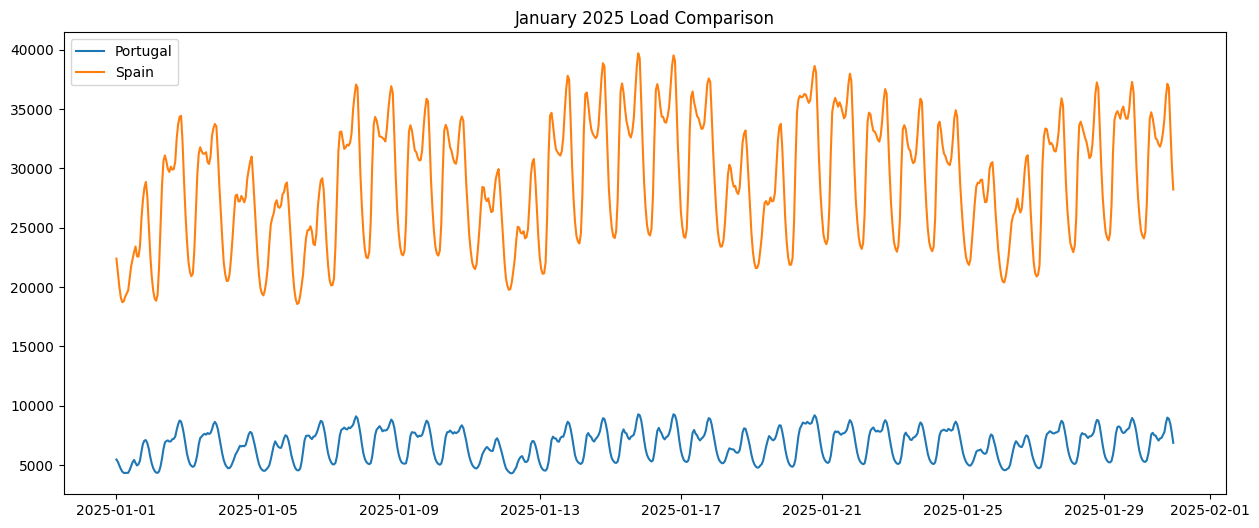

In [21]:
plt.figure(figsize=(15,6))

plt.plot(df_pt.loc["2025-01-01":"2025-01-30"].index,
         df_pt.loc["2025-01-01":"2025-01-30"]["Value"],
         label="Portugal")

plt.plot(df_es.loc["2025-01-01":"2025-01-30"].index,
         df_es.loc["2025-01-01":"2025-01-30"]["Value"],
         label="Spain")

plt.title("January 2025 Load Comparison")
plt.legend()
plt.savefig("../results/january.png", dpi=300)
plt.show()

In [13]:
# Normalize Portugal
df_pt_norm = (df_pt["Value"] - df_pt["Value"].min()) / (df_pt["Value"].max() - df_pt["Value"].min())

# Normalize Spain
df_es_norm = (df_es["Value"] - df_es["Value"].min()) / (df_es["Value"].max() - df_es["Value"].min())

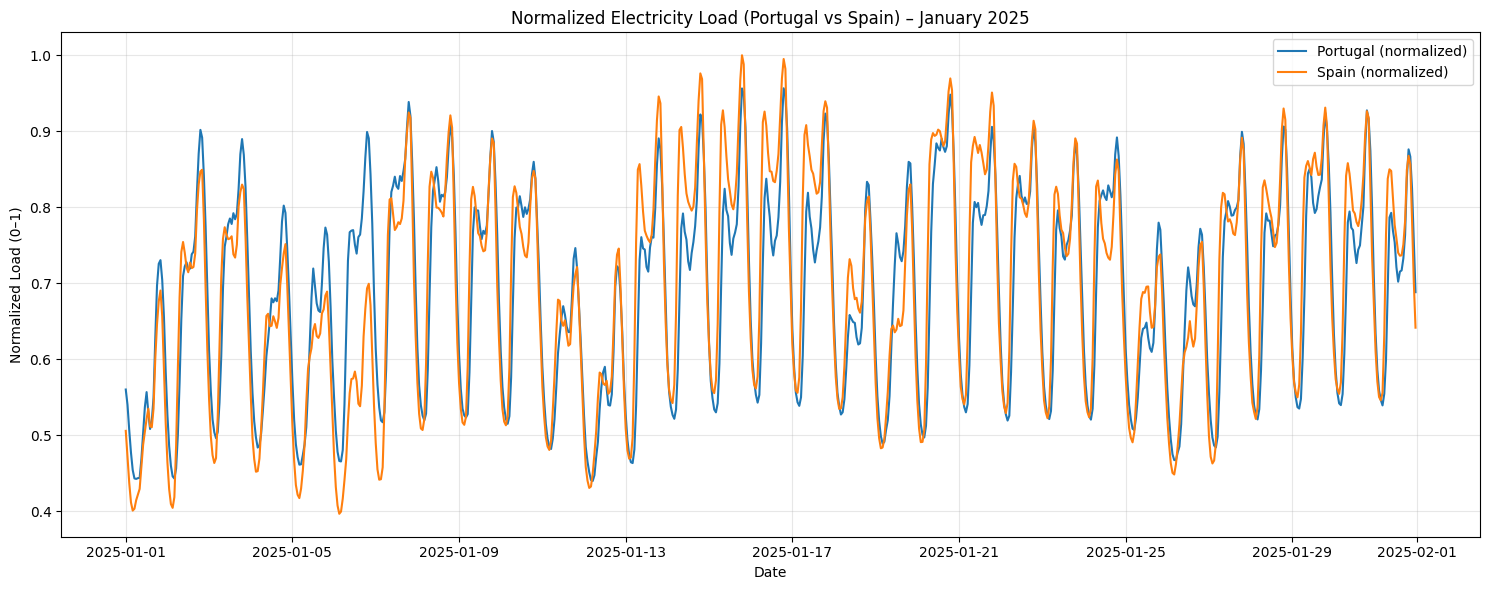

In [19]:
start = "2025-01-01"
end = "2025-01-31"

plt.figure(figsize=(15,6))

plt.plot(df_pt_norm.loc[start:end].index,
         df_pt_norm.loc[start:end],
         label="Portugal (normalized)")

plt.plot(df_es_norm.loc[start:end].index,
         df_es_norm.loc[start:end],
         label="Spain (normalized)")

plt.title("Normalized Electricity Load (Portugal vs Spain) – January 2025")
plt.xlabel("Date")
plt.ylabel("Normalized Load (0–1)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/normalized_january.png", dpi=300)
plt.show()


The objective of this study is to compare the forecasting ability of SARIMA and LSTM models on hourly electricity demand series for Portugal and Spain, and to examine whether the additional complexity of LSTM provides meaningful gains over a well-specified seasonal time series model.

That last one is very strong because it introduces the key tension:

SARIMA = simpler, interpretable, seasonal
LSTM = flexible, nonlinear, more complex

Sub-questions you can explicitly test

You can structure the experiment around these:

.Which model produces lower forecasting error for Portugal and Spain?
.How well does each model capture daily and weekly seasonality?
.Does LSTM provide a substantial improvement over SARIMA, or does SARIMA remain competitive?
.Are forecasting results consistent across both countries?
.How do the models behave during demand peaks and unusual drops?
.Hypotheses you can state


If you want a more formal report style:

H1: Both SARIMA and LSTM can capture the strong seasonal structure of hourly electricity demand.
H2: LSTM may outperform SARIMA when temporal dynamics are more complex or nonlinear.
H3: Given the strong regular seasonality of electricity load, SARIMA may remain highly competitive despite its lower complexit

How to formulate the forecasting task itself

Be very explicit:

Forecast target

Forecast hourly electricity load (Value) for Portugal and Spain.

Forecast horizon

Choose one and state it clearly:

1-step ahead forecasting: predict the next hour
24-step ahead forecasting: predict the next 24 hours

For your project, a good formulation is:

The models are trained to forecast hourly electricity demand using past observations, and their performance is evaluated on an out-of-sample test period.

Or more specifically:

SARIMA and LSTM are used to generate one-step-ahead and/or day-ahead forecasts of hourly electricity demand, and their predictive accuracy is compared using MAE, RMSE, and MAPE.

Best experimental framing

A very solid methodology sentence would be:

The forecasting exercise is designed as an out-of-sample comparison between SARIMA and LSTM, using the same training and test periods for both models in order to ensure a fair evaluation.

That matters a lot. Professors like seeing:

same data
same forecast horizon
same evaluation metrics
How to justify SARIMA vs LSTM

You should say something like:

SARIMA is included because it is a standard benchmark for seasonal time series and offers interpretability through explicit autoregressive, differencing, and seasonal components. LSTM is included because it can model complex nonlinear temporal dependencies without requiring the same parametric assumptions.

That sentence is excellent for the methodology section.

A ready-to-use paragraph for your report

You can adapt this directly:

This project compares two forecasting approaches for hourly electricity demand in Portugal and Spain: SARIMA, representing classical seasonal time series modeling, and LSTM, representing deep learning-based sequence modeling. The objective is to assess which approach provides more accurate forecasts and whether the additional flexibility of LSTM leads to better performance than a well-specified statistical benchmark. The comparison is carried out using the same time period, forecasting horizon, and evaluation metrics, allowing a consistent assessment of model accuracy and practical suitability.

Simplest final formulation to use

If you want one sentence to anchor the whole project, use this:

The project aims to compare SARIMA and LSTM models in forecasting hourly electricity demand in Portugal and Spain, evaluating whether the higher complexity of LSTM leads to better predictive performance than a classical seasonal time series model.

Next, the best thing is to decide your forecast horizon and train/test split, because that determines the